Device: cuda | Input features per timestep: 18
Train: (913000, 3)  2013-01-01 → 2017-12-31
Test : (45000, 3)   2018-01-01  → 2018-03-31

Building features & decomposing ...
Train windows: 732,000 | Val windows: 47,000

Model parameters: 718,394
Input size: 2 cont + 16 emb = 18  (calendar used as index only)
Epoch   1/40 | Train sMAPE-loss: 0.1858 | Val sMAPE (raw): 13.04%
Epoch   5/40 | Train sMAPE-loss: 0.1484 | Val sMAPE (raw): 12.48%
Epoch  10/40 | Train sMAPE-loss: 0.1457 | Val sMAPE (raw): 12.27%
Epoch  15/40 | Train sMAPE-loss: 0.1437 | Val sMAPE (raw): 12.22%
Epoch  20/40 | Train sMAPE-loss: 0.1426 | Val sMAPE (raw): 12.09%
Epoch  25/40 | Train sMAPE-loss: 0.1417 | Val sMAPE (raw): 12.03%
Epoch  30/40 | Train sMAPE-loss: 0.1411 | Val sMAPE (raw): 12.09%
Epoch  35/40 | Train sMAPE-loss: 0.1407 | Val sMAPE (raw): 12.09%
Epoch  40/40 | Train sMAPE-loss: 0.1405 | Val sMAPE (raw): 12.08%

Best Val sMAPE (raw sales): 12.02%


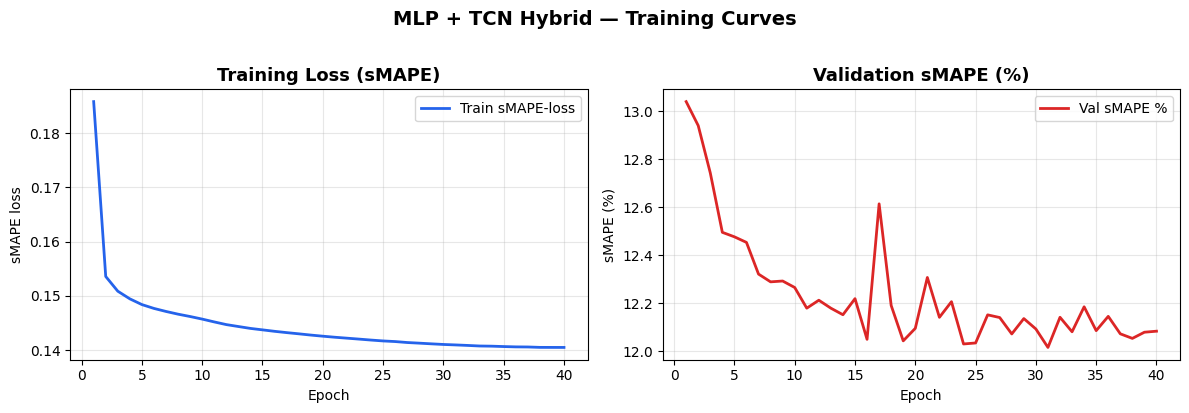

Loss plot saved → losses.png


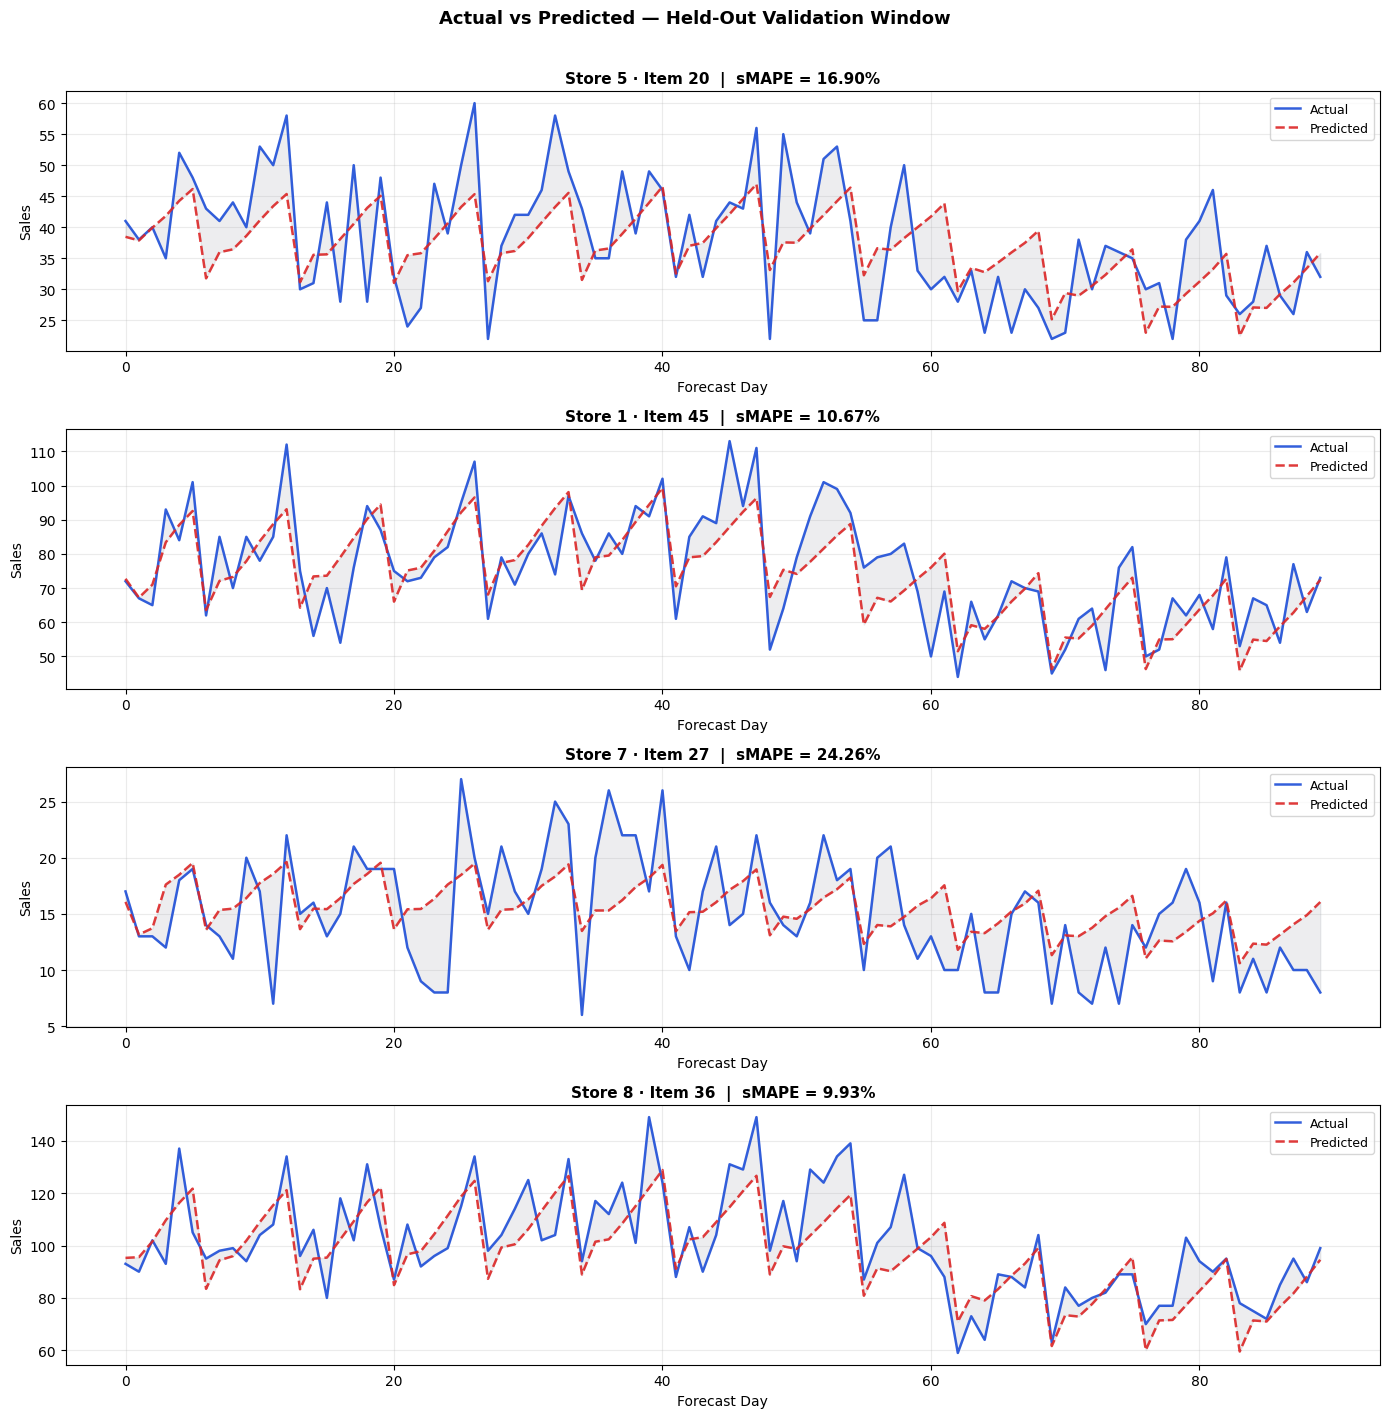

Actual vs Predicted plot saved → actual_vs_pred.png

Generating forecasts ...

Submission saved → submission.csv
 id     sales
  0 12.208941
  1 14.898032
  2 14.936543
  3 15.401667
  4 16.413132
  5 17.713171
  6 18.804867
  7 12.058414
  8 14.156324
  9 14.230026


In [1]:
"""
Demand Forecasting: Multivariate Hybrid MLP (trend) + TCN (seasonality)
=========================================================================
LSTM replaced with a lightweight MLP branch for trend modeling.
Adds: training/val loss plot and actual vs predicted plot.

Multivariate inputs per timestep:
  1. sales_trend  – moving-average trend of raw sales
  2. sales_season – seasonal residual (raw sales − trend)
  3. store_emb    – learnable store embedding (10 stores)
  4. item_emb     – learnable item embedding  (50 items)
  → Total: 2 continuous + emb_dim*2 = INPUT_SIZE

Calendar features (sin/cos) used as time INDEX only — NOT model inputs.
No normalization applied anywhere.
sMAPE computed on raw sales values.

Kaggle data paths:
  /kaggle/input/competitions/demand-forecasting-kernels-only/train.csv
  /kaggle/input/competitions/demand-forecasting-kernels-only/test.csv
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
TRAIN_PATH      = "/kaggle/input/competitions/demand-forecasting-kernels-only/train.csv"
TEST_PATH       = "/kaggle/input/competitions/demand-forecasting-kernels-only/test.csv"
OUTPUT_PATH     = "submission.csv"

SEQ_LEN          = 90
PRED_LEN         = 90
SEASONAL_PERIOD  = 7

NUM_STORES       = 10
NUM_ITEMS        = 50
EMB_DIM          = 8

BATCH_SIZE       = 128
EPOCHS           = 40
LR               = 3e-4
# MLP replaces LSTM — much lighter
MLP_HIDDEN       = [256, 128]   # hidden layer sizes for the MLP branch
TCN_CHANNELS     = [64, 128, 128]
KERNEL_SIZE      = 3
DROPOUT          = 0.2

INPUT_SIZE = 2 + EMB_DIM * 2   # trend + season + store_emb + item_emb

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE} | Input features per timestep: {INPUT_SIZE}")


# ─────────────────────────────────────────────
# 1. DATA LOADING
# ─────────────────────────────────────────────
def load_data(train_path: str, test_path: str):
    train = pd.read_csv(train_path, parse_dates=["date"], index_col="date")
    test  = pd.read_csv(test_path,  parse_dates=["date"], index_col="date")
    for df in [train, test]:
        df["store"] = df["store"] - 1
        df["item"]  = df["item"]  - 1
    print(f"Train: {train.shape}  {train.index.min().date()} → {train.index.max().date()}")
    print(f"Test : {test.shape}   {test.index.min().date()}  → {test.index.max().date()}")
    return train, test


# ─────────────────────────────────────────────
# 2. DECOMPOSITION
# ─────────────────────────────────────────────
def moving_average(x: np.ndarray, period: int) -> np.ndarray:
    kernel = np.ones(period) / period
    trend  = np.convolve(x, kernel, mode="same")
    half   = period // 2
    trend[:half]  = trend[half]
    trend[-half:] = trend[-half - 1]
    return trend


def decompose(x: np.ndarray, period: int = 7):
    trend      = moving_average(x, period).astype(np.float32)
    seasonality = (x - trend).astype(np.float32)
    return trend, seasonality


# ─────────────────────────────────────────────
# 3. CALENDAR FEATURES  (index only)
# ─────────────────────────────────────────────
def calendar_features(dates: pd.DatetimeIndex) -> np.ndarray:
    dow  = dates.dayofweek.values
    doy  = dates.dayofyear.values
    mon  = dates.month.values
    feats = np.stack([
        np.sin(2 * np.pi * dow / 7),   np.cos(2 * np.pi * dow / 7),
        np.sin(2 * np.pi * doy / 365), np.cos(2 * np.pi * doy / 365),
        np.sin(2 * np.pi * mon / 12),  np.cos(2 * np.pi * mon / 12),
    ], axis=1).astype(np.float32)
    return feats


# ─────────────────────────────────────────────
# 4. BUILD FLAT FEATURE MATRIX
# ─────────────────────────────────────────────
def build_feature_matrix(df: pd.DataFrame):
    records = []
    for (store, item), grp in df.groupby(["store", "item"]):
        grp = grp.sort_index()
        raw    = grp["sales"].values.astype(np.float32)
        trend, season = decompose(raw, SEASONAL_PERIOD)
        feats  = np.stack([trend, season], axis=1)  # (T, 2)
        cal    = calendar_features(grp.index)        # (T, 6)  — index only
        n      = len(grp)
        records.append({
            "features"  : feats,
            "cal_index" : cal,
            "store_ids" : np.full(n, store, dtype=np.int64),
            "item_ids"  : np.full(n, item,  dtype=np.int64),
            "sales"     : raw,
        })
    return records


# ─────────────────────────────────────────────
# 5. DATASET
# ─────────────────────────────────────────────
class MultivariateTSDataset(Dataset):
    def __init__(self, records, seq_len: int, pred_len: int):
        self.seq_len  = seq_len
        self.pred_len = pred_len
        self.samples  = []
        for r in records:
            T = len(r["sales"])
            for start in range(T - seq_len - pred_len + 1):
                end   = start + seq_len
                t_end = end + pred_len
                self.samples.append((
                    r["features"][start:end],
                    r["store_ids"][0],
                    r["item_ids"][0],
                    r["sales"][end:t_end],
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feats, store, item, target = self.samples[idx]
        return (
            torch.tensor(feats,   dtype=torch.float32),
            torch.tensor(store,   dtype=torch.long),
            torch.tensor(item,    dtype=torch.long),
            torch.tensor(target,  dtype=torch.float32),
        )


# ─────────────────────────────────────────────
# 6. MODEL COMPONENTS
# ─────────────────────────────────────────────

class IDEmbedder(nn.Module):
    def __init__(self, num_stores, num_items, emb_dim):
        super().__init__()
        self.store_emb = nn.Embedding(num_stores, emb_dim)
        self.item_emb  = nn.Embedding(num_items,  emb_dim)

    def forward(self, store_ids, item_ids, seq_len):
        s   = self.store_emb(store_ids)
        i   = self.item_emb(item_ids)
        emb = torch.cat([s, i], dim=-1)
        return emb.unsqueeze(1).expand(-1, seq_len, -1)


# ── MLP branch  (replaces LSTM — lightweight trend head) ────────────────
class MLPBranch(nn.Module):
    """
    Flattens the (seq_len, input_size) window and passes it through an MLP.
    Much lighter than LSTM: no recurrence, no hidden state.
    """
    def __init__(self, input_size, seq_len, hidden_sizes, pred_len, dropout=0.2):
        super().__init__()
        flat_in = input_size * seq_len
        layers  = []
        prev    = flat_in
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, pred_len))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, seq_len, input_size)
        B = x.size(0)
        return self.net(x.reshape(B, -1))   # (B, pred_len)


# ── Causal dilated conv ──────────────────────
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv  = nn.Conv1d(in_ch, out_ch, kernel_size,
                               padding=pad, dilation=dilation)
        self.chomp = pad

    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.chomp] if self.chomp > 0 else out


class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch,  out_ch, kernel_size, dilation),
            nn.ReLU(), nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel_size, dilation),
            nn.ReLU(), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = self.downsample(x) if self.downsample else x
        return self.relu(out + res)


class TCNBranch(nn.Module):
    def __init__(self, input_size, channels, kernel_size=3, pred_len=90, dropout=0.2):
        super().__init__()
        layers, in_ch = [], input_size
        for i, out_ch in enumerate(channels):
            layers.append(TCNBlock(in_ch, out_ch, kernel_size,
                                   dilation=2**i, dropout=dropout))
            in_ch = out_ch
        self.network = nn.Sequential(*layers)
        self.fc      = nn.Linear(channels[-1], pred_len)

    def forward(self, x):
        x   = x.permute(0, 2, 1)
        out = self.network(x)
        return self.fc(out[:, :, -1])


# ── Full hybrid model ────────────────────────
class HybridForecastModel(nn.Module):
    """
    MLP (trend) + TCN (seasonality) hybrid.
    MLP is stateless and ~3–4× lighter than a 2-layer LSTM.
    Calendar features used as time index only — NOT model inputs.
    """

    def __init__(self, num_stores, num_items, emb_dim,
                 cont_size, seq_len,
                 mlp_hidden, tcn_channels, kernel_size,
                 pred_len, dropout):
        super().__init__()
        self.embedder   = IDEmbedder(num_stores, num_items, emb_dim)
        full_input      = cont_size + emb_dim * 2   # 2 + 16 = 18

        self.mlp_branch = MLPBranch(
            input_size=full_input, seq_len=seq_len,
            hidden_sizes=mlp_hidden, pred_len=pred_len, dropout=dropout,
        )
        self.tcn_branch = TCNBranch(
            input_size=full_input, channels=tcn_channels,
            kernel_size=kernel_size, pred_len=pred_len, dropout=dropout,
        )
        self.fusion = nn.Sequential(
            nn.Linear(pred_len * 2, pred_len * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(pred_len * 2, pred_len),
        )

    def forward(self, x_cont, store_ids, item_ids):
        B, T, _ = x_cont.shape
        emb = self.embedder(store_ids, item_ids, T)
        x   = torch.cat([x_cont, emb], dim=-1)

        t_pred = self.mlp_branch(x)    # (B, pred_len)
        s_pred = self.tcn_branch(x)    # (B, pred_len)

        fused = torch.cat([t_pred, s_pred], dim=-1)
        out   = self.fusion(fused)
        return torch.relu(out)


# ─────────────────────────────────────────────
# 7. METRICS
# ─────────────────────────────────────────────
def smape_np(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask  = denom > 1e-8
    return 100.0 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])


def smape_loss(pred: torch.Tensor, true: torch.Tensor) -> torch.Tensor:
    denom = (torch.abs(true) + torch.abs(pred)) / 2.0
    denom = torch.clamp(denom, min=1e-8)
    return torch.mean(torch.abs(pred - true) / denom)


# ─────────────────────────────────────────────
# 8. TRAIN / EVAL LOOPS
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for x, store, item, y in loader:
        x, store, item, y = (t.to(DEVICE) for t in (x, store, item, y))
        optimizer.zero_grad()
        pred = model(x, store, item)
        loss = smape_loss(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    for x, store, item, y in loader:
        x, store, item = x.to(DEVICE), store.to(DEVICE), item.to(DEVICE)
        p = model(x, store, item).cpu().numpy()
        preds.append(p)
        trues.append(y.numpy())
    return smape_np(np.concatenate(trues), np.concatenate(preds))


# ─────────────────────────────────────────────
# 9. PLOTTING HELPERS
# ─────────────────────────────────────────────
def plot_losses(train_losses, val_smapes, save_path="losses.png"):
    """Plot training sMAPE-loss and validation sMAPE side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(train_losses) + 1)

    axes[0].plot(epochs, train_losses, color="#2563EB", linewidth=2, label="Train sMAPE-loss")
    axes[0].set_title("Training Loss (sMAPE)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("sMAPE loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, val_smapes, color="#DC2626", linewidth=2, label="Val sMAPE %")
    axes[1].set_title("Validation sMAPE (%)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("sMAPE (%)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.suptitle("MLP + TCN Hybrid — Training Curves", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Loss plot saved → {save_path}")


def plot_actual_vs_predicted(model, val_records, record_map,
                              n_series=4, save_path="actual_vs_pred.png"):
    """
    For n_series random (store, item) series, plot actual vs predicted
    over the last SEQ_LEN + PRED_LEN steps.
    """
    model.eval()
    fig, axes = plt.subplots(n_series, 1, figsize=(14, 3.5 * n_series))
    if n_series == 1:
        axes = [axes]

    rng     = np.random.default_rng(42)
    keys    = list(record_map.keys())
    chosen  = rng.choice(len(keys), size=min(n_series, len(keys)), replace=False)

    for ax, idx in zip(axes, chosen):
        store, item = keys[idx]
        r = record_map[(store, item)]

        ctx_feats = r["features"][-SEQ_LEN - PRED_LEN : -PRED_LEN]   # (SEQ_LEN, 2)
        actual    = r["sales"][-PRED_LEN:]                             # (PRED_LEN,)

        x_ctx = torch.tensor(ctx_feats).unsqueeze(0).to(DEVICE)
        s_id  = torch.tensor([store], dtype=torch.long).to(DEVICE)
        i_id  = torch.tensor([item],  dtype=torch.long).to(DEVICE)

        with torch.no_grad():
            pred = model(x_ctx, s_id, i_id).cpu().numpy().flatten()
        pred = np.maximum(pred, 0.0)

        horizon = np.arange(PRED_LEN)
        ax.plot(horizon, actual, color="#1D4ED8", linewidth=1.8,
                label="Actual", alpha=0.9)
        ax.plot(horizon, pred,   color="#DC2626", linewidth=1.8,
                linestyle="--", label="Predicted", alpha=0.9)
        ax.fill_between(horizon, actual, pred,
                        alpha=0.12, color="#6B7280")

        series_smape = smape_np(actual, pred)
        ax.set_title(f"Store {store+1} · Item {item+1}  |  sMAPE = {series_smape:.2f}%",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Forecast Day")
        ax.set_ylabel("Sales")
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, alpha=0.25)

    plt.suptitle("Actual vs Predicted — Held-Out Validation Window",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Actual vs Predicted plot saved → {save_path}")


# ─────────────────────────────────────────────
# 10. MAIN PIPELINE
# ─────────────────────────────────────────────
def run_pipeline():
    # ── Load ──────────────────────────────────
    train_df, test_df = load_data(TRAIN_PATH, TEST_PATH)

    # ── Feature records ───────────────────────
    print("\nBuilding features & decomposing ...")
    train_records = build_feature_matrix(train_df)

    train_recs, val_recs = [], []
    for r in train_records:
        T     = len(r["sales"])
        split = int(T * 0.9)
        def slice_rec(r, s, e):
            return {k: v[s:e] if isinstance(v, np.ndarray) else v
                    for k, v in r.items()}
        train_recs.append(slice_rec(r, 0, split))
        val_recs.append(slice_rec(r, split - SEQ_LEN, T))

    train_ds = MultivariateTSDataset(train_recs, SEQ_LEN, PRED_LEN)
    val_ds   = MultivariateTSDataset(val_recs,   SEQ_LEN, PRED_LEN)
    print(f"Train windows: {len(train_ds):,} | Val windows: {len(val_ds):,}")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  drop_last=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, drop_last=False, num_workers=0)

    # ── Model ─────────────────────────────────
    CONT_SIZE = 2
    model = HybridForecastModel(
        num_stores   = NUM_STORES,
        num_items    = NUM_ITEMS,
        emb_dim      = EMB_DIM,
        cont_size    = CONT_SIZE,
        seq_len      = SEQ_LEN,
        mlp_hidden   = MLP_HIDDEN,
        tcn_channels = TCN_CHANNELS,
        kernel_size  = KERNEL_SIZE,
        pred_len     = PRED_LEN,
        dropout      = DROPOUT,
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel parameters: {total_params:,}")
    print(f"Input size: {CONT_SIZE} cont + {EMB_DIM*2} emb = {CONT_SIZE + EMB_DIM*2}"
          f"  (calendar used as index only)")
    print("=" * 60)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_smape, best_state = float("inf"), None
    train_losses, val_smapes = [], []   # ← track every epoch for plots

    for epoch in range(1, EPOCHS + 1):
        tr_loss   = train_one_epoch(model, train_loader, optimizer)
        val_smape = evaluate(model, val_loader) if len(val_ds) > 0 else float("nan")
        scheduler.step()

        train_losses.append(tr_loss)
        val_smapes.append(val_smape)

        if val_smape < best_smape:
            best_smape = val_smape
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{EPOCHS} | "
                  f"Train sMAPE-loss: {tr_loss:.4f} | "
                  f"Val sMAPE (raw): {val_smape:.2f}%")

    print(f"\nBest Val sMAPE (raw sales): {best_smape:.2f}%")
    model.load_state_dict(best_state)

    # ── Plot training curves ───────────────────
    plot_losses(train_losses, val_smapes, save_path="losses.png")

    # ── Plot actual vs predicted ───────────────
    all_records = build_feature_matrix(train_df)
    record_map  = {(r["store_ids"][0], r["item_ids"][0]): r for r in all_records}
    plot_actual_vs_predicted(model, val_recs, record_map,
                             n_series=4, save_path="actual_vs_pred.png")

    # ── Inference ─────────────────────────────
    print("\nGenerating forecasts ...")
    model.eval()
    rows = []
    test_grouped = test_df.groupby(["store", "item"])

    with torch.no_grad():
        for (store, item), grp in test_grouped:
            grp   = grp.sort_index()
            tr    = record_map[(store, item)]
            ctx   = tr["features"][-SEQ_LEN:]                         # (SEQ_LEN, 2)
            x_ctx = torch.tensor(ctx).unsqueeze(0).to(DEVICE)
            s_id  = torch.tensor([store], dtype=torch.long).to(DEVICE)
            i_id  = torch.tensor([item],  dtype=torch.long).to(DEVICE)
            pred  = model(x_ctx, s_id, i_id).cpu().numpy().flatten()
            pred  = np.maximum(pred, 0.0)

            for i, (idx, row) in enumerate(grp.iterrows()):
                if i < len(pred):
                    rows.append({
                        "id"   : int(row["id"]) if "id" in row else f"{idx}_{store}_{item}",
                        "sales": float(pred[i]),
                    })

    submission = pd.DataFrame(rows)
    submission.to_csv(OUTPUT_PATH, index=False)
    print(f"\nSubmission saved → {OUTPUT_PATH}")
    print(submission.head(10).to_string(index=False))
    return model, submission


# ─────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model, submission = run_pipeline()